# Practice Deep Learning 

In [1948]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import torch

In [1949]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScienceNotes/DeepLearning/Titanic-Dataset.csv.xls" )

X - Information about the passengers
y - whether they survived ( 0 - Did not survive, 1 - did survive) [ Binary Classification]

In [1950]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1951]:
df.shape

(891, 12)

In [1952]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [1953]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [1954]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [1955]:
y = df['Survived']

In [1956]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

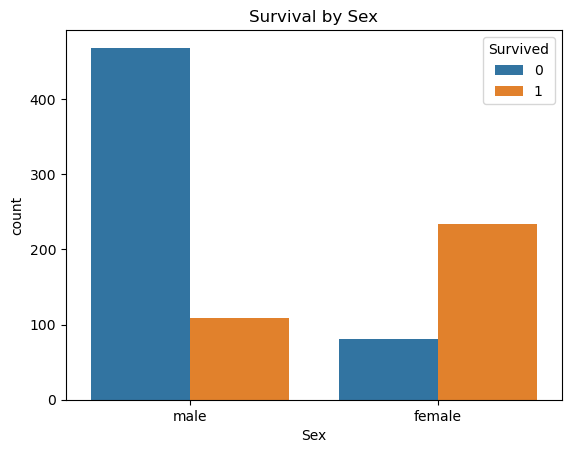

In [1957]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

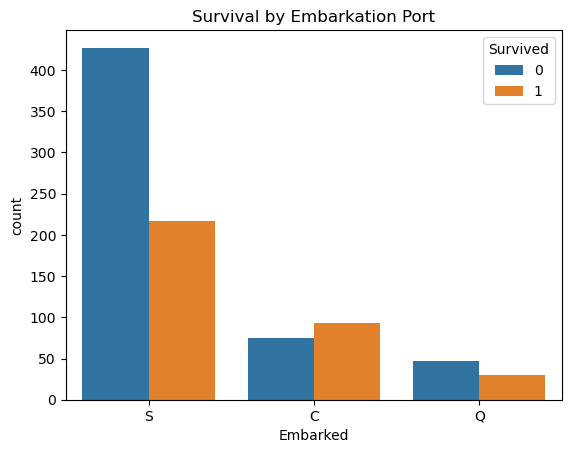

In [1958]:
sns.countplot(data=df, x="Embarked", hue="Survived")
plt.title("Survival by Embarkation Port")
plt.show()

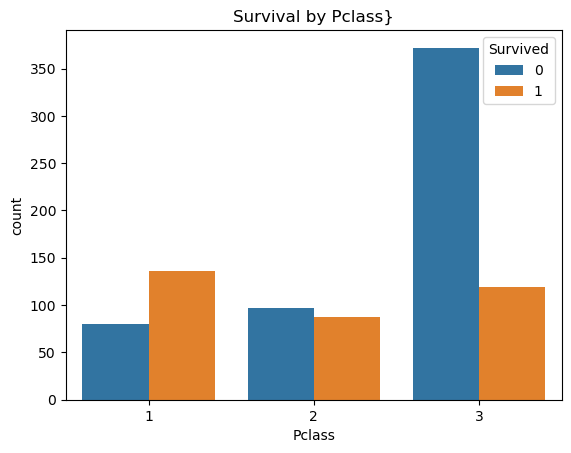

In [1959]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Pclass}")
plt.show()

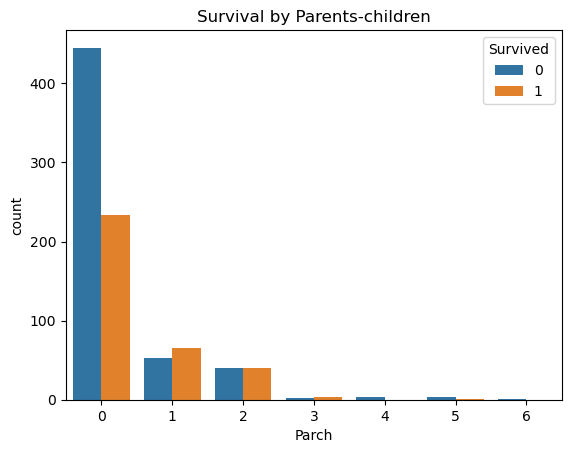

In [1960]:
sns.countplot(data=df, x="Parch", hue="Survived")
plt.title("Survival by Parents-children")
plt.show()

In [1961]:
# age is continuous, need grouupby
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


Text(0.5, 1.0, 'Age Distribution by Survival')

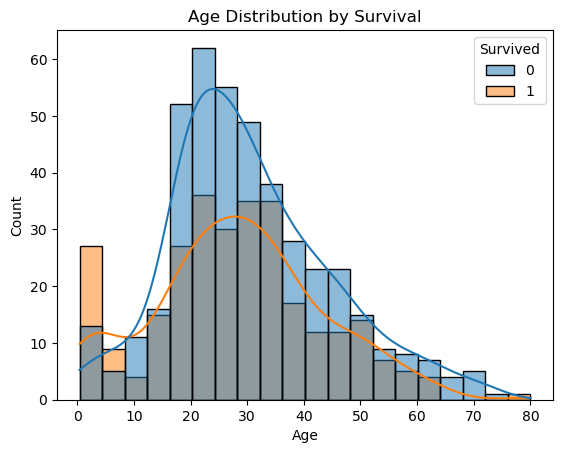

In [1962]:
sns.histplot(data=df, x = 'Age', hue = 'Survived', kde = True)
plt.title("Age Distribution by Survival")

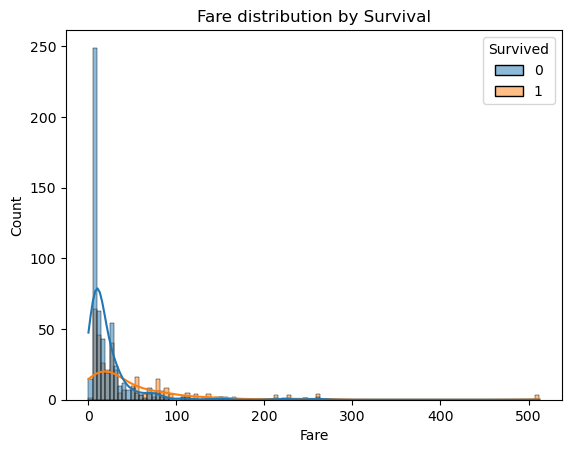

In [1963]:
# seems weird, edit later

sns.histplot(data=df, x= 'Fare', hue = 'Survived', kde = True)
plt.title("Fare distribution by Survival")
plt.show()

In [1964]:
# feature eng

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

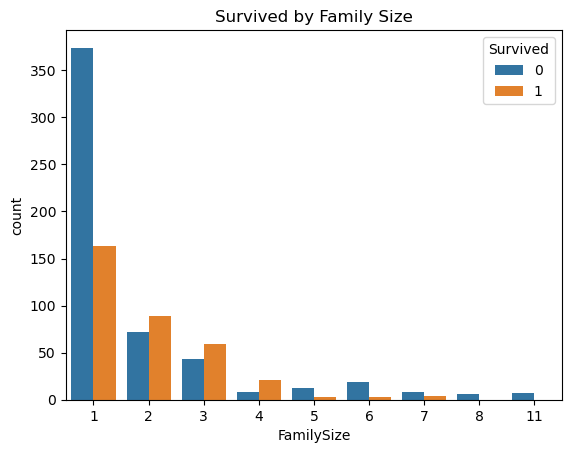

In [1965]:
sns.countplot(data=df, x='FamilySize', hue='Survived')
plt.title("Survived by Family Size")
plt.show()

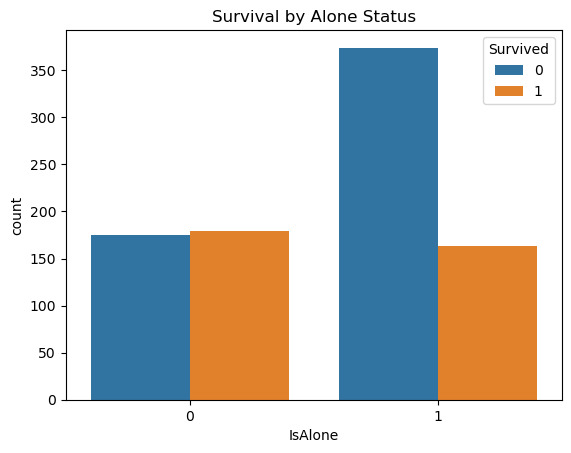

In [1966]:
sns.countplot(data=df, x='IsAlone', hue = 'Survived')
plt.title("Survival by Alone Status")
plt.show()

## Feature Set

In [1967]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked',
    'FamilySize',
    'IsAlone'
]

target = 'Survived'

X = df[features]
y = df[target]

In [1968]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


In [1969]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [1970]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train: ", X_train.shape)
print("Validate: ", X_val.shape)
print("Test: ", X_test.shape)


Train:  (623, 9)
Validate:  (134, 9)
Test:  (134, 9)


## Preprocessing Pipeline

In [1971]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'IsAlone'
]

categorical_features = [
    'Sex',
    'Embarked'
]

In [1972]:
# Age contains missing values, fill missing values witht the median and standardize the variables
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Neural network trains more effectively when numerical inputs are on comparable scales

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# The two missing embarked values are replaced by the most frequent category

preprocesor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [1973]:
X_train_processed = preprocesor.fit_transform(X_train)
X_val_processed = preprocesor.transform(X_val)
X_test_processed = preprocesor.transform(X_test)

In [1974]:
print(type(X_train_processed))
print(X_train_processed.shape)
print(X_train_processed.dtype)

<class 'numpy.ndarray'>
(623, 12)
float64


In [1975]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [1976]:
# numpy to pytorch tensors

X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# for numeric, we use floating point

In [1977]:
print(X_train_tensor.shape)
print(X_train_tensor.dtype)

print(y_train_tensor.shape)
print(y_train_tensor.dtype)

torch.Size([623, 12])
torch.float32
torch.Size([623])
torch.float32


In [1978]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [1979]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True
)

In [1980]:
import torch.nn as nn

# number of inpute features
input_f = X_train_tensor.shape[1]
print(input_f)

12


In [1981]:
# Why do we add ReLU? - introduces nonlinear transformation

class TitanicModel(nn.Module):


    def __init__(self, input_f):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_f, 32),
            nn.ReLU(),
            # Adding a dropout feature - more resistent to overfitting
            # nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),
            # nn.Dropout(0.2)

            nn.Linear(16, 1)
        )
            

    def forward(self, x):
        return self.network(x)

In [1982]:
model = TitanicModel(input_f)
print(model)

TitanicModel(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [1983]:
# forward pass

X_batch, y_batch = next(iter(train_loader))
outputs = model(X_batch)
print(outputs.shape)

print(outputs[:5])
# these are logits, we need probabilities between 0 and 1

probs = torch.sigmoid(outputs)
print(probs[:5]) # now, values are between 0 to 1


# for binary classification, we need a threshold of 0.5
predictions = (probs >= 0.5).float()

torch.Size([32, 1])
tensor([[0.2648],
        [0.2404],
        [0.2578],
        [0.1477],
        [0.3275]], grad_fn=<SliceBackward0>)
tensor([[0.5658],
        [0.5598],
        [0.5641],
        [0.5369],
        [0.5811]], grad_fn=<SliceBackward0>)


In [1984]:
# Loss and Gradients 

criterion = nn.BCEWithLogitsLoss() # combines sigmoid and binary cross entropy

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001, # controls getting stuck
    weight_decay = 0.0001
    #momentum = 0.9 # to avoid getting stuck at the first dip of the function 
)

In [1985]:
num_epochs = 30
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # training

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(1), y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)
    train_losses.append(average_train_loss)

    # validation 
    model.eval()

    total_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(1), y_batch)
            total_val_loss += loss.item()

    average_val_loss = total_val_loss / len(val_loader)
    val_losses.append(average_val_loss)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Val Loss:  {average_val_loss:.4f}"
    )

Epoch 1/30 | Train loss: 0.7043 | Val Loss:  0.6801
Epoch 2/30 | Train loss: 0.6636 | Val Loss:  0.6512
Epoch 3/30 | Train loss: 0.6178 | Val Loss:  0.5907
Epoch 4/30 | Train loss: 0.5598 | Val Loss:  0.5273
Epoch 5/30 | Train loss: 0.5159 | Val Loss:  0.4721
Epoch 6/30 | Train loss: 0.4815 | Val Loss:  0.4249
Epoch 7/30 | Train loss: 0.4563 | Val Loss:  0.4376
Epoch 8/30 | Train loss: 0.4430 | Val Loss:  0.4335
Epoch 9/30 | Train loss: 0.4358 | Val Loss:  0.4080
Epoch 10/30 | Train loss: 0.4251 | Val Loss:  0.3940
Epoch 11/30 | Train loss: 0.4299 | Val Loss:  0.3506
Epoch 12/30 | Train loss: 0.4194 | Val Loss:  0.3438
Epoch 13/30 | Train loss: 0.4167 | Val Loss:  0.3430
Epoch 14/30 | Train loss: 0.4143 | Val Loss:  0.3799
Epoch 15/30 | Train loss: 0.4089 | Val Loss:  0.3381
Epoch 16/30 | Train loss: 0.4104 | Val Loss:  0.4089
Epoch 17/30 | Train loss: 0.4091 | Val Loss:  0.3401
Epoch 18/30 | Train loss: 0.4089 | Val Loss:  0.3980
Epoch 19/30 | Train loss: 0.4061 | Val Loss:  0.3525
Ep

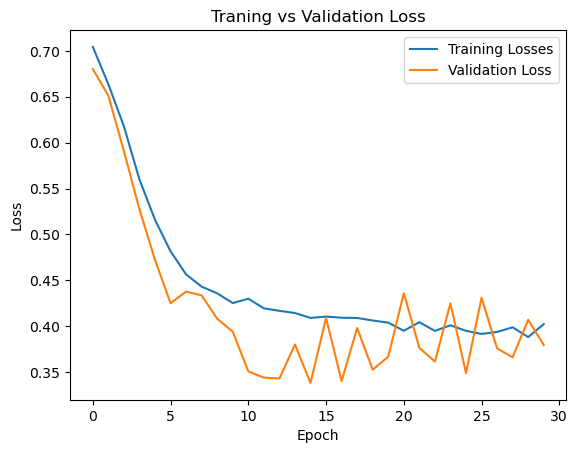

In [1986]:
plt.plot(train_losses, label = "Training Losses")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Traning vs Validation Loss")

plt.legend()
plt.show()


## Evaluation Section


In [1992]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score, 
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

model.eval()

all_predictions = []
all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs).squeeze(1)
        predictions = (probs >= 0.5).float()

        all_probs.extend(probs.numpy())
        all_predictions.extend(predictions.numpy())
        all_targets.extend(y_batch.numpy())


print(classification_report(all_targets, all_predictions))
print(confusion_matrix(all_targets, all_predictions))

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88        82
         1.0       0.86      0.71      0.78        52

    accuracy                           0.84       134
   macro avg       0.85      0.82      0.83       134
weighted avg       0.84      0.84      0.84       134

[[76  6]
 [15 37]]


In [1996]:
import pandas as pd

results = pd.DataFrame({
    "actual": all_targets,
    "predicted": all_predictions,
    "probability": all_probs
})

errors = results[
    results["actual"] != results["predicted"]
]

print(errors)

     actual  predicted  probability
3       1.0        0.0     0.087824
23      1.0        0.0     0.499832
27      1.0        0.0     0.321703
31      1.0        0.0     0.333483
43      1.0        0.0     0.132929
45      1.0        0.0     0.289798
47      1.0        0.0     0.186998
56      1.0        0.0     0.464284
57      1.0        0.0     0.274998
63      0.0        1.0     0.721357
66      1.0        0.0     0.213874
76      1.0        0.0     0.323667
81      1.0        0.0     0.319488
90      0.0        1.0     0.944774
93      0.0        1.0     0.532047
94      0.0        1.0     0.672490
99      1.0        0.0     0.094516
105     1.0        0.0     0.125715
122     0.0        1.0     0.825173
128     0.0        1.0     0.785484
132     1.0        0.0     0.274998


In [1988]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_processed,
    y_train
)

LogisticRegression(max_iter=1000)

In [1989]:
lr_predictions = logistic_model.predict(
    X_val_processed
)

lr_probabilities = logistic_model.predict_proba(
    X_val_processed
)[:, 1]

In [1995]:
print(
    "Report:",
    classification_report(y_val, lr_predictions)
)

print(confusion_matrix(y_val, lr_predictions))


Report:               precision    recall  f1-score   support

           0       0.86      0.89      0.87        82
           1       0.82      0.77      0.79        52

    accuracy                           0.84       134
   macro avg       0.84      0.83      0.83       134
weighted avg       0.84      0.84      0.84       134

[[73  9]
 [12 40]]
